<a href="https://colab.research.google.com/github/saeedzainab274-bit/Brain-Tumor-Deep-Learning-project/blob/main/BrainTumor_Project(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import os

# Create the directories if they don't exist
os.makedirs(yes_path, exist_ok=True)
os.makedirs(no_path, exist_ok=True)

print(f"Created directory: {yes_path}")
print(f"Created directory: {no_path}")

Created directory: /content/yes
Created directory: /content/no


In [14]:
# Unzip the archive containing the dataset
import zipfile
import os

archive_path = '/content/archive.zip'
extraction_path = '/content/'

if os.path.exists(archive_path):
    with zipfile.ZipFile(archive_path, 'r') as zip_ref:
        zip_ref.extractall(extraction_path)
    print(f"'{archive_path}' extracted to '{extraction_path}'.")
else:
    print(f"Archive file '{archive_path}' not found.")

'/content/archive.zip' extracted to '/content/'.


In [15]:
import shutil
import os

# Define source and destination paths based on common archive structure
source_base_path = '/content/brain_tumor_dataset'
source_yes_folder = os.path.join(source_base_path, 'yes')
source_no_folder = os.path.join(source_base_path, 'no')

# Destination paths are already defined in the kernel from cell xIl0sQvmIyFN
dest_yes_folder = yes_path # /content/yes
dest_no_folder = no_path   # /content/no

def move_files(source_dir, dest_dir):
    if os.path.exists(source_dir):
        print(f"Moving files from '{source_dir}' to '{dest_dir}'...")
        for filename in os.listdir(source_dir):
            source_file_path = os.path.join(source_dir, filename)
            dest_file_path = os.path.join(dest_dir, filename)

            # If the destination file already exists, remove it first to allow overwriting
            if os.path.exists(dest_file_path):
                os.remove(dest_file_path)
                # print(f"Removed existing file: {dest_file_path}") # Optional: for debugging

            shutil.move(source_file_path, dest_dir)
        print(f"Finished moving files from '{source_dir}'.")
        # Clean up the now empty source directory
        os.rmdir(source_dir)
    else:
        print(f"Source directory '{source_dir}' does not exist. Skipping move operation.")

move_files(source_yes_folder, dest_yes_folder)
move_files(source_no_folder, dest_no_folder)

# Clean up the base extracted directory if it's empty
if os.path.exists(source_base_path) and not os.listdir(source_base_path):
    os.rmdir(source_base_path)
    print(f"Removed empty base directory '{source_base_path}'.")


Moving files from '/content/brain_tumor_dataset/yes' to '/content/yes'...
Finished moving files from '/content/brain_tumor_dataset/yes'.
Moving files from '/content/brain_tumor_dataset/no' to '/content/no'...
Finished moving files from '/content/brain_tumor_dataset/no'.
Removed empty base directory '/content/brain_tumor_dataset'.


**Task 1.2: Data Validation.**

In [16]:
import os

yes_path = "/content/yes"
no_path = "/content/no"

print("Tumor Images:", len(os.listdir(yes_path)))
print("No Tumor Images:", len(os.listdir(no_path)))

total = len(os.listdir(yes_path)) + len(os.listdir(no_path))
print("Total Images:", total)


Tumor Images: 155
No Tumor Images: 98
Total Images: 253


**Check for Corrupted Images**

In [17]:
from PIL import Image
import os

def check_images(folder):
    bad_images = []

    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            bad_images.append(img_name)

    return bad_images

bad_yes = check_images("/content/yes")
bad_no = check_images("/content/no")

print("Corrupted Tumor Images:", len(bad_yes))
print("Corrupted No Tumor Images:", len(bad_no))

Corrupted Tumor Images: 0
Corrupted No Tumor Images: 0


**Show Sample Images**

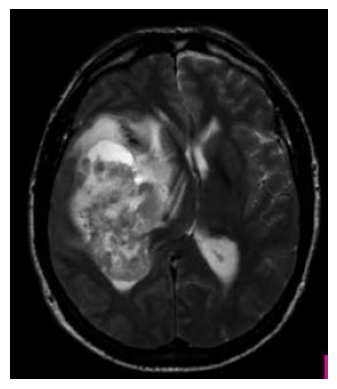

In [18]:
import matplotlib.pyplot as plt
from PIL import Image
import os

tumor_image = os.listdir("/content/yes")[0]
img = Image.open(f"/content/yes/{tumor_image}")

plt.imshow(img)
plt.axis("off")
plt.show()


**Task 1.3: Preprocessing (Resize + Normalize Images**

**Import Libraries**

In [20]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

Create Data Generator

In [21]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.15
)

**Create Training Data**

In [22]:
train_data = datagen.flow_from_directory(
    "/content",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

Found 216 images belonging to 4 classes.


**Create Validation Data**

In [23]:
val_data = datagen.flow_from_directory(
    "/content",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 37 images belonging to 4 classes.


**Task 1.4 Train/Test Split**



In [24]:
print(train_data.class_indices)

{'.config': 0, 'no': 1, 'sample_data': 2, 'yes': 3}


**Visualize Processed Images**

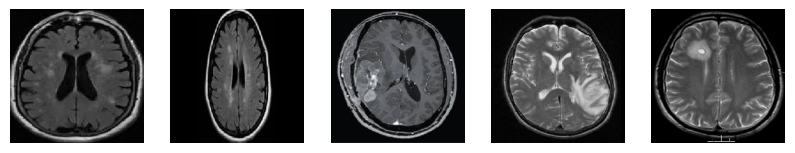

In [25]:
import matplotlib.pyplot as plt

images, labels = next(train_data)

plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()